In [14]:
import pandas as pd
import torch
import numpy as np
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_curve, auc

In [2]:
df_test = pd.read_csv('PreprocecedDatasets/TestSet.csv')
df_test.head()

,Unnamed: 0,CommentText,VideoTitle,Sentiment,CommentCleand,VideoCleaned,FullText,label
0,19626,"I really appreciate your videos, but why did y...",Data Structures and Algorithms for Beginners,Negative,"I really appreciate your videos, but why did y...",Data Structures and Algorithms for Beginners,Data Structures and Algorithms for Beginners [...,0
1,67251,Sure is a lot of “friends” attacking people.. ...,"Akron teenager kidnapped, held in basement whi...",Negative,Sure is a lot of “friends” attacking people.. ...,"Akron teenager kidnapped, held in basement whi...","Akron teenager kidnapped, held in basement whi...",0
2,20101,Worlds poweeful emmotion love 🥰🥰,A man saved a mountain lion and raise it with ...,Positive,Worlds poweeful emmotion love smiling face wit...,A man saved a mountain lion and raise it with ...,A man saved a mountain lion and raise it with ...,1
3,37688,"Hi sir,\nThis year Data Science and Data Engin...",What is Data Science?,Positive,"Hi sir, This year Data Science and Data Engine...",What is Data Science?,"What is Data Science? [SEP] Hi sir, This year ...",1
4,62614,Wow idol,HALA GRABE CONFIRMED!TRILLANES BINULGAR BOBONG...,Positive,Wow idol,HALA GRABE CONFIRMED!TRILLANES BINULGAR BOBONG...,HALA GRABE CONFIRMED!TRILLANES BINULGAR BOBONG...,1


In [3]:
MODEL_PATH = "./fine_tuned_youtube_sentiment"

analyzer = pipeline(
    "text-classification", 
    model=MODEL_PATH, 
    tokenizer=MODEL_PATH,
    truncation=True,
    max_length=512,
    device=0 if torch.cuda.is_available() else -1
)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 521.38it/s]


In [4]:
raw_predictions = analyzer(df_test['FullText'].to_list(), batch_size=64)
raw_predictions

[{'label': 'LABEL_0', 'score': 0.9934098124504089},
 {'label': 'LABEL_0', 'score': 0.9685201644897461},
 {'label': 'LABEL_1', 'score': 0.9965304732322693},
 {'label': 'LABEL_1', 'score': 0.9949560761451721},
 {'label': 'LABEL_1', 'score': 0.9861321449279785},
 {'label': 'LABEL_0', 'score': 0.9966337084770203},
 {'label': 'LABEL_0', 'score': 0.9947406649589539},
 {'label': 'LABEL_1', 'score': 0.9963717460632324},
 {'label': 'LABEL_1', 'score': 0.9985033273696899},
 {'label': 'LABEL_0', 'score': 0.9023349285125732},
 {'label': 'LABEL_0', 'score': 0.9945701956748962},
 {'label': 'LABEL_1', 'score': 0.9508516192436218},
 {'label': 'LABEL_1', 'score': 0.9264907240867615},
 {'label': 'LABEL_0', 'score': 0.6835934519767761},
 {'label': 'LABEL_0', 'score': 0.9889074563980103},
 {'label': 'LABEL_0', 'score': 0.9918720126152039},
 {'label': 'LABEL_0', 'score': 0.5972305536270142},
 {'label': 'LABEL_0', 'score': 0.9929686188697815},
 {'label': 'LABEL_1', 'score': 0.9970048069953918},
 {'label': '

In [7]:
label_map = {"LABEL_0": 0, "LABEL_1": 1}

df_test['predicted_label'] = [label_map[pred['label']] for pred in raw_predictions]
df_test['confidence_score'] = [pred['score'] for pred in raw_predictions]
df_test['confidence_class1'] = df_test['confidence_class1'] = np.where(df_test['predicted_label'] == 0, 1 - df_test['confidence_score'], df_test['confidence_score'])

df_test.head()

,Unnamed: 0,CommentText,VideoTitle,Sentiment,CommentCleand,VideoCleaned,FullText,label,predicted_label,confidence_score,confidence_class1
0,19626,"I really appreciate your videos, but why did y...",Data Structures and Algorithms for Beginners,Negative,"I really appreciate your videos, but why did y...",Data Structures and Algorithms for Beginners,Data Structures and Algorithms for Beginners [...,0,0,0.993410,0.006590
1,67251,Sure is a lot of “friends” attacking people.. ...,"Akron teenager kidnapped, held in basement whi...",Negative,Sure is a lot of “friends” attacking people.. ...,"Akron teenager kidnapped, held in basement whi...","Akron teenager kidnapped, held in basement whi...",0,0,0.968520,0.031480
2,20101,Worlds poweeful emmotion love 🥰🥰,A man saved a mountain lion and raise it with ...,Positive,Worlds poweeful emmotion love smiling face wit...,A man saved a mountain lion and raise it with ...,A man saved a mountain lion and raise it with ...,1,1,0.996530,0.996530
3,37688,"Hi sir,\nThis year Data Science and Data Engin...",What is Data Science?,Positive,"Hi sir, This year Data Science and Data Engine...",What is Data Science?,"What is Data Science? [SEP] Hi sir, This year ...",1,1,0.994956,0.994956
4,62614,Wow idol,HALA GRABE CONFIRMED!TRILLANES BINULGAR BOBONG...,Positive,Wow idol,HALA GRABE CONFIRMED!TRILLANES BINULGAR BOBONG...,HALA GRABE CONFIRMED!TRILLANES BINULGAR BOBONG...,1,1,0.986132,0.986132


In [8]:
y_true = df_test['label']
y_pred = df_test['predicted_label']

In [9]:
print(f'accuracy : {accuracy_score(y_true, y_pred)*100:.2f}%')
print(classification_report(y_true, y_pred))

accuracy : 86.97%
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      3000
           1       0.90      0.83      0.86      3000

    accuracy                           0.87      6000
   macro avg       0.87      0.87      0.87      6000
weighted avg       0.87      0.87      0.87      6000



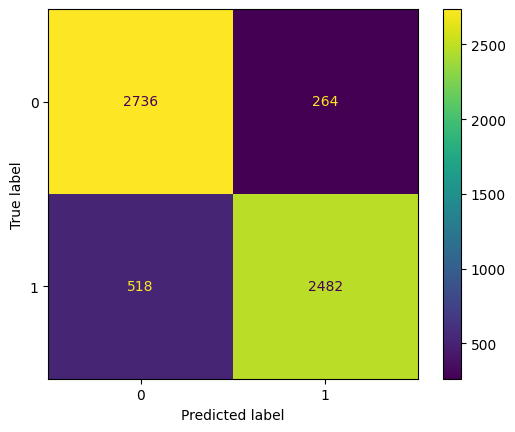

In [10]:
ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

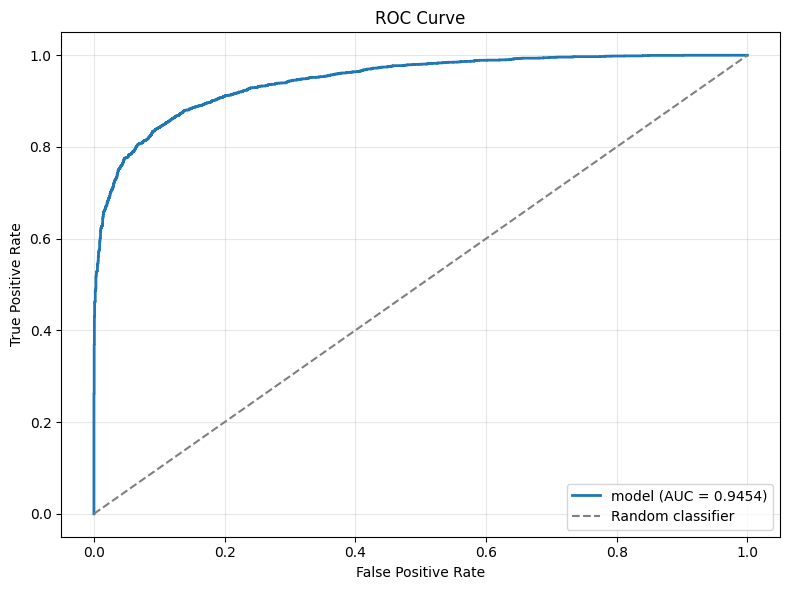

In [ ]:
import matplotlib.pyplot as plt

y_proba = df_test['confidence_class1']

fpr, tpr, _ = roc_curve(y_true, y_proba)
auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"model (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()